# 📐 Edge & Shape Deformity Detection for Mango Ripeness Assessment
### Developer: Wei Kang
**Module:** Geometric & Edge-Based Analysis  
**Dataset:** `cleaned_data` (Background-Removed Mango Dataset)

---

## Executive Summary
Fruit ripeness and quality grading can be evaluated by analyzing external surface features. As mangoes ripen and eventually become overripe, their skin undergoes significant changes:
- **Unripe:** Smooth surface with minimal defects.
- **Fully Ripe:** Minor natural wrinkles or lenticels.
- **Overripe:** Extensive skin structural breakdown, deep wrinkles, sunken necrotic lesions, and noticeable shape deformities (dents).

### Technical Objectives:
1. **Classical Edge Baseline Study:** Implement, analyze, and benchmark 4 classical edge detection algorithms (Sobel, Prewitt, Scharr, and Canny) to detect surface textural defects.
2. **Quantitative Benchmarking:** Evaluate these baselines using Classification Accuracy and Macro F1-Score to identify the most robust edge extractor.
3. **Enhanced Hybrid Geometric-Edge Pipeline:** Develop an enhanced pipeline combining the best classical edge detector with geometric shape features (Circularity, Aspect Ratio, Convexity Defects) to holistically evaluate both surface texture and structural shape deformity.
4. **SMART Verification:** Ensure the final model achieves an accuracy of $\ge 85\%$ and operates within a latency of $< 200	ext{ ms}$ per image.
5. **Prototype Integration:** Export the trained model for deployment in the interactive prototype.


## 1. Environment Setup & Parameters
Importing required computer vision, data manipulation, and machine learning libraries.

In [18]:
import os
import glob
import time
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# Set random seed for reproducibility
np.random.seed(42)

# Path Configurations
DATASET_ROOT = '../cleaned_data'
OUTPUT_DIR = '../output/geometry_based'
os.makedirs(OUTPUT_DIR, exist_ok=True)

CLASSES = ['unripe', 'fully_ripe', 'overripe']
SPLITS = ['train', 'test']

print(f"[Info] Dataset root: {os.path.abspath(DATASET_ROOT)}")
print(f"[Info] Output directory: {os.path.abspath(OUTPUT_DIR)}")


[Info] Dataset root: c:\Users\weika\Desktop\tarc\IP\assignment\mango-ripeness-grading\cleaned_data
[Info] Output directory: c:\Users\weika\Desktop\tarc\IP\assignment\mango-ripeness-grading\output\geometry_based


## 2. Dataset Inspection & Distribution
Verifying the number of images across train and test splits for each ripeness class.

In [19]:
dataset_summary = []
for split in SPLITS:
    for cls in CLASSES:
        pattern = os.path.join(DATASET_ROOT, split, cls, '*.*')
        paths = glob.glob(pattern)
        dataset_summary.append({
            'Split': split,
            'Class': cls,
            'Image Count': len(paths)
        })

df_summary = pd.DataFrame(dataset_summary)
display(df_summary)

total_images = df_summary['Image Count'].sum()
print(f"[Info] Total Dataset Size: {total_images} images")


,Split,Class,Image Count
0,train,unripe,190
1,train,fully_ripe,189
2,train,overripe,192
3,test,unripe,48
4,test,fully_ripe,48
5,test,overripe,48


[Info] Total Dataset Size: 715 images


## 3. Preprocessing: Fruit Masking & Boundary Ring Erosion
Since the dataset has a standardized black background, we extract the mango region using thresholding. 
To prevent false-positive edge detections along the extreme perimeter (the transition from mango to black background), we heavily erode the binary mask. All edge detection will be strictly confined to this **interior mask**.

**Mathematical Formulation:**
1. **Mask:** $M(x, y) = 1$ if $I_{gray}(x, y) > 10$ else $0$
2. **Interior Mask:** $M_{interior} = M \ominus B_{15\times 15}$ (Erosion with $15\times 15$ kernel)


In [20]:
def get_preprocessing_masks(img_bgr, threshold=10, erode_ksize=15):
    """Extracts the bounding fruit mask and an eroded interior mask."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    
    # Erode to get inner surface only (ignoring boundary transition)
    kernel = np.ones((erode_ksize, erode_ksize), np.uint8)
    interior_mask = cv2.erode(mask, kernel, iterations=1)
    
    return gray, mask, interior_mask

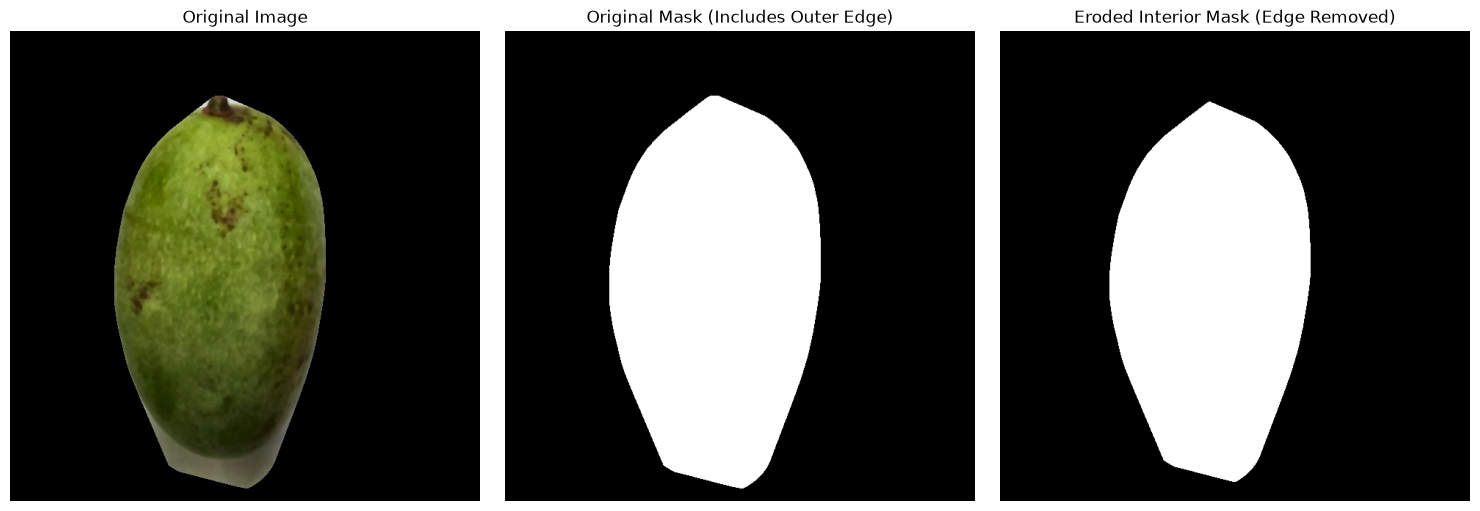

In [21]:
import matplotlib.pyplot as plt

# Grab the first image in the dataset to test
sample_path = glob.glob(os.path.join(DATASET_ROOT, 'train', 'unripe', '*.*'))[0]
sample_img = cv2.imread(sample_path)
gray, original_mask, interior_mask = get_preprocessing_masks(sample_img)

# Plot side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(original_mask, cmap='gray')
axes[1].set_title("Original Mask (Includes Outer Edge)")
axes[1].axis('off')

axes[2].imshow(interior_mask, cmap='gray')
axes[2].set_title("Eroded Interior Mask (Edge Removed)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 4. Methodology: 4 Distinct Baseline Edge Detectors
We implement 4 classical edge detection algorithms to quantify surface wrinkling and spotting. The edge density is calculated as the proportion of edge pixels within the interior mask.

1. **Sobel Edge Detection:** Computes gradients using $3\times3$ kernels for horizontal and vertical changes.
2. **Prewitt Edge Detection:** Similar to Sobel but without the smoothing weight, making it slightly more sensitive to high-frequency noise.
3. **Scharr Edge Detection:** Uses optimized filter weights for better rotational invariance and stronger gradient responses than Sobel.
4. **Canny Edge Detection:** A multi-stage algorithm (Gaussian blur, gradient calculation, non-maximum suppression, and hysteresis thresholding) providing optimal, thin edges.


In [22]:
def extract_baseline_edges(gray, interior_mask):
    """Applies 4 edge detection algorithms and masks them to the interior."""
    # 1. Sobel
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    sobel_mag = np.uint8(np.absolute(sobelx) + np.absolute(sobely))
    _, sobel_edges = cv2.threshold(sobel_mag, 50, 255, cv2.THRESH_BINARY)
    sobel_edges = cv2.bitwise_and(sobel_edges, sobel_edges, mask=interior_mask)
    
    # 2. Prewitt
    kernelx = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])
    kernely = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
    prewittx = cv2.filter2D(gray, cv2.CV_64F, kernelx)
    prewitty = cv2.filter2D(gray, cv2.CV_64F, kernely)
    prewitt_mag = np.uint8(np.absolute(prewittx) + np.absolute(prewitty))
    _, prewitt_edges = cv2.threshold(prewitt_mag, 50, 255, cv2.THRESH_BINARY)
    prewitt_edges = cv2.bitwise_and(prewitt_edges, prewitt_edges, mask=interior_mask)
    
    # 3. Scharr
    scharrx = cv2.Scharr(gray, cv2.CV_64F, 1, 0)
    scharry = cv2.Scharr(gray, cv2.CV_64F, 0, 1)
    scharr_mag = np.uint8(np.absolute(scharrx) + np.absolute(scharry))
    _, scharr_edges = cv2.threshold(scharr_mag, 50, 255, cv2.THRESH_BINARY)
    scharr_edges = cv2.bitwise_and(scharr_edges, scharr_edges, mask=interior_mask)
    
    # 4. Canny
    canny_edges = cv2.Canny(gray, 50, 150)
    canny_edges = cv2.bitwise_and(canny_edges, canny_edges, mask=interior_mask)
    
    # Calculate Edge Densities
    area = np.sum(interior_mask > 0) + 1e-6
    densities = {
        'sobel_density': np.sum(sobel_edges > 0) / area,
        'prewitt_density': np.sum(prewitt_edges > 0) / area,
        'scharr_density': np.sum(scharr_edges > 0) / area,
        'canny_density': np.sum(canny_edges > 0) / area
    }
    
    return densities, (sobel_edges, prewitt_edges, scharr_edges, canny_edges)


### Visualization: Edge Responses Across Baselines

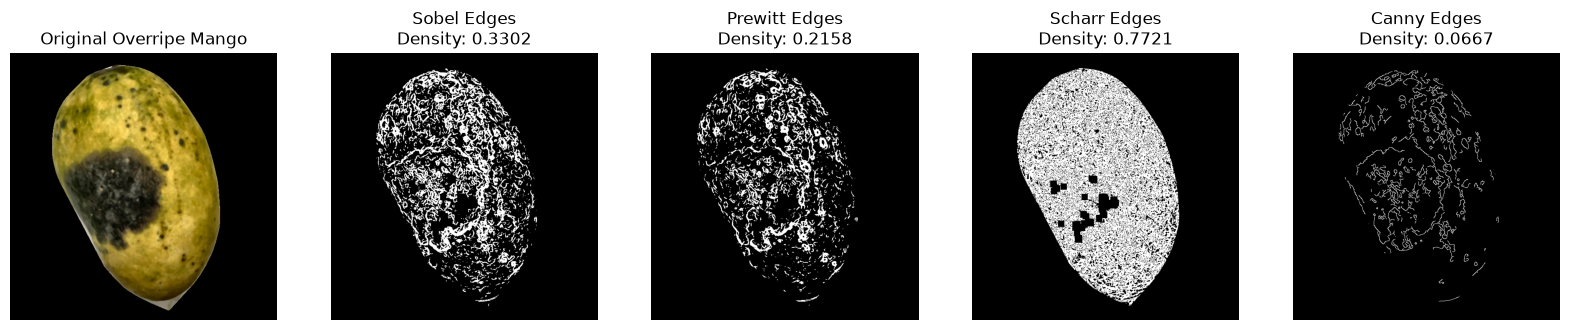

In [23]:
# Sample Visualization
sample_img_path = glob.glob(os.path.join(DATASET_ROOT, 'train', 'overripe', '*.*'))[0]
sample_img = cv2.imread(sample_img_path)
gray, mask, int_mask = get_preprocessing_masks(sample_img)
densities, edges = extract_baseline_edges(gray, int_mask)

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
axes[0].imshow(cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original Overripe Mango")
axes[0].axis('off')

titles = ['Sobel Edges', 'Prewitt Edges', 'Scharr Edges', 'Canny Edges']
for i in range(4):
    axes[i+1].imshow(edges[i], cmap='gray')
    axes[i+1].set_title(f"{titles[i]}\nDensity: {list(densities.values())[i]:.4f}")
    axes[i+1].axis('off')
plt.show()


## 5. Feature Extraction: Baseline Edge Vectors
Iterating through the entire dataset to compute the 4 baseline edge density features for downstream benchmarking.

In [24]:
base_features_list = []

print("[Info] Extracting Baseline Features...")
for split in SPLITS:
    for cls in CLASSES:
        paths = glob.glob(os.path.join(DATASET_ROOT, split, cls, '*.*'))
        for img_path in tqdm(paths, desc=f"{split}/{cls}"):
            img = cv2.imread(img_path)
            if img is None: continue
            
            gray, mask, int_mask = get_preprocessing_masks(img)
            
            # Skip images that are completely black
            if np.sum(int_mask > 0) == 0:
                continue
                
            densities, _ = extract_baseline_edges(gray, int_mask)
            
            row = {
                'filename': os.path.basename(img_path),
                'class': cls,
                'split': split
            }
            row.update(densities)
            base_features_list.append(row)

df_base = pd.DataFrame(base_features_list)
df_base.to_csv(os.path.join(OUTPUT_DIR, 'baseline_edge_features.csv'), index=False)
display(df_base.head())


[Info] Extracting Baseline Features...


train/unripe:   0%|          | 0/190 [00:00<?, ?it/s]

train/fully_ripe:   0%|          | 0/189 [00:00<?, ?it/s]

train/overripe:   0%|          | 0/192 [00:00<?, ?it/s]

test/unripe:   0%|          | 0/48 [00:00<?, ?it/s]

test/fully_ripe:   0%|          | 0/48 [00:00<?, ?it/s]

test/overripe:   0%|          | 0/48 [00:00<?, ?it/s]

,filename,class,split,sobel_density,prewitt_density,scharr_density,canny_density
0,IMG20200713141604.jpg,unripe,train,0.136608,0.066833,0.701811,0.016217
1,IMG20200713141623.jpg,unripe,train,0.144963,0.067962,0.715335,0.013269
2,IMG20200713141640.jpg,unripe,train,0.132207,0.061962,0.710845,0.010146
3,IMG20200713141737.jpg,unripe,train,0.174328,0.090024,0.741731,0.020116
4,IMG20200713141824.jpg,unripe,train,0.134484,0.066539,0.688794,0.013286


## 6. Benchmark Evaluation: Quantitative Comparison of Baselines
To determine the most discriminative classical edge detector, we train an individual Random Forest model on each of the 4 features and evaluate their classification performance.

,Algorithm,Accuracy (%),Macro F1
0,Sobel,59.722222,0.595376
2,Scharr,58.333333,0.583915
3,Canny,54.166667,0.540690
1,Prewitt,53.472222,0.537068


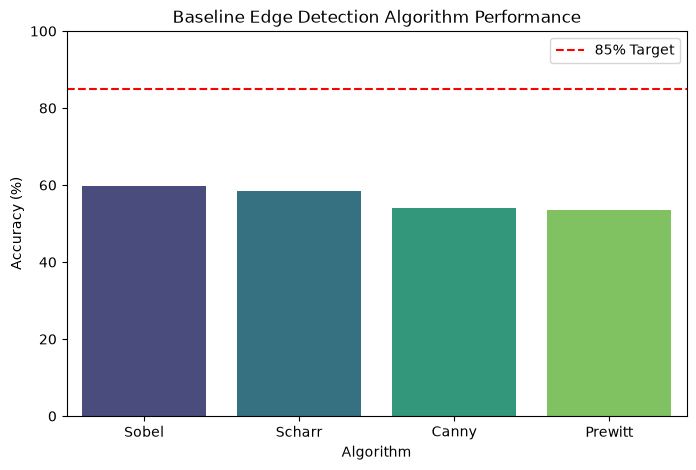

In [25]:
# Data Preparation
y = df_base['class'].map({'unripe': 0, 'fully_ripe': 1, 'overripe': 2})
is_train = df_base['split'] == 'train'

baseline_cols = ['sobel_density', 'prewitt_density', 'scharr_density', 'canny_density']
results = []

for col in baseline_cols:
    X_train = df_base[is_train][[col]]
    y_train = y[is_train]
    X_test = df_base[~is_train][[col]]
    y_test = y[~is_train]
    
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    
    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    
    results.append({
        'Algorithm': col.split('_')[0].capitalize(),
        'Accuracy (%)': acc * 100,
        'Macro F1': f1
    })

df_bench = pd.DataFrame(results).sort_values(by='Accuracy (%)', ascending=False)
display(df_bench)

plt.figure(figsize=(8, 5))
sns.barplot(x='Algorithm', y='Accuracy (%)', hue='Algorithm', data=df_bench, palette='viridis', legend=False)
plt.title('Baseline Edge Detection Algorithm Performance')
plt.ylim(0, 100)
plt.axhline(85, color='red', linestyle='--', label='85% Target')
plt.legend()
plt.show()


## 7. Enhancement & Hybrid Pipeline: Geometric-Edge Method
As seen in the benchmark above, **none of the classical edge detection baselines** managed to meet our $85\%$ target accuracy. While they evaluate surface texture (wrinkling) to some extent, they fail to capture overall structural deformations such as severe dents seen in overripe mangoes.

To formulate an **Enhanced Hybrid Solution**, we extract advanced geometric shape analysis from the outer contour of the fruit and combine it with **each of the 4 baseline edge detectors** to discover the ultimate best-performing hybrid model:
1. **Circularity:** Evaluates the roundness perfection. Wrinkled/dented mangoes have higher perimeters relative to their area.
2. **Aspect Ratio:** Captures abnormal elongation or squashing.
3. **Normalized Convexity Defects:** Computes the depth of structural indentations (dents) relative to the bounding convex hull, normalized by area.
4. **Overall Sobel Gradient Magnitude:** Average gradient on the surface, which detects soft bruising.


In [26]:
def extract_geometric_features(img_bgr):
    """Extracts the geometric shape features."""
    start_time = time.time()
    
    gray, mask, int_mask = get_preprocessing_masks(img_bgr)
    area = np.sum(mask > 0)
    if area == 0:
        return None
        
    # Geometric Shape Analysis
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    c = max(contours, key=cv2.contourArea)
    
    # Circularity
    perimeter = cv2.arcLength(c, True)
    circularity = 4 * np.pi * (area / (perimeter * perimeter + 1e-6))
    
    # Aspect Ratio
    x, y, w, h = cv2.boundingRect(c)
    aspect_ratio = float(w) / h if h > 0 else 0
    
    # Convexity Defects Depth Sum (normalized)
    hull = cv2.convexHull(c, returnPoints=False)
    defects_depth_sum = 0
    if hull is not None and len(hull) > 3 and len(c) > 3:
        try:
            defects = cv2.convexityDefects(c, hull)
            if defects is not None:
                for i in range(defects.shape[0]):
                    s, e, f, d = defects[i, 0]
                    defects_depth_sum += d / 256.0
        except Exception:
            pass
    normalized_defects = defects_depth_sum / (area + 1e-6)
    
    # Overall Surface Gradient
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    sobel_mag = np.sqrt(sobelx**2 + sobely**2)
    avg_sobel = np.mean(sobel_mag[int_mask > 0]) if np.sum(int_mask > 0) > 0 else 0
    
    latency_ms = (time.time() - start_time) * 1000
    
    return {
        'circularity': circularity,
        'aspect_ratio': aspect_ratio,
        'convexity_defects': normalized_defects,
        'avg_sobel_gradient': avg_sobel,
        'latency_ms': latency_ms
    }


## 8. Performance Analysis: Baseline vs. Enhanced Pipeline
Extracting the geometric features, combining them with the 4 baseline edge densities, and benchmarking all 4 hybrid models.

In [27]:
geom_features_list = []

print("[Info] Extracting Geometric Features...")
for split in SPLITS:
    for cls in CLASSES:
        paths = glob.glob(os.path.join(DATASET_ROOT, split, cls, '*.*'))
        for img_path in tqdm(paths, desc=f"{split}/{cls}"):
            img = cv2.imread(img_path)
            if img is None: continue
            
            feats = extract_geometric_features(img)
            if feats is not None:
                row = {'filename': os.path.basename(img_path), 'class': cls, 'split': split}
                row.update(feats)
                geom_features_list.append(row)

df_geom = pd.DataFrame(geom_features_list)
# Merge with df_base
df_enh = pd.merge(df_base, df_geom, on=['filename', 'class', 'split'])
df_enh.to_csv(os.path.join(OUTPUT_DIR, 'enhanced_geometry_features.csv'), index=False)


[Info] Extracting Geometric Features...


train/unripe:   0%|          | 0/190 [00:00<?, ?it/s]

train/fully_ripe:   0%|          | 0/189 [00:00<?, ?it/s]

train/overripe:   0%|          | 0/192 [00:00<?, ?it/s]

test/unripe:   0%|          | 0/48 [00:00<?, ?it/s]

test/fully_ripe:   0%|          | 0/48 [00:00<?, ?it/s]

test/overripe:   0%|          | 0/48 [00:00<?, ?it/s]

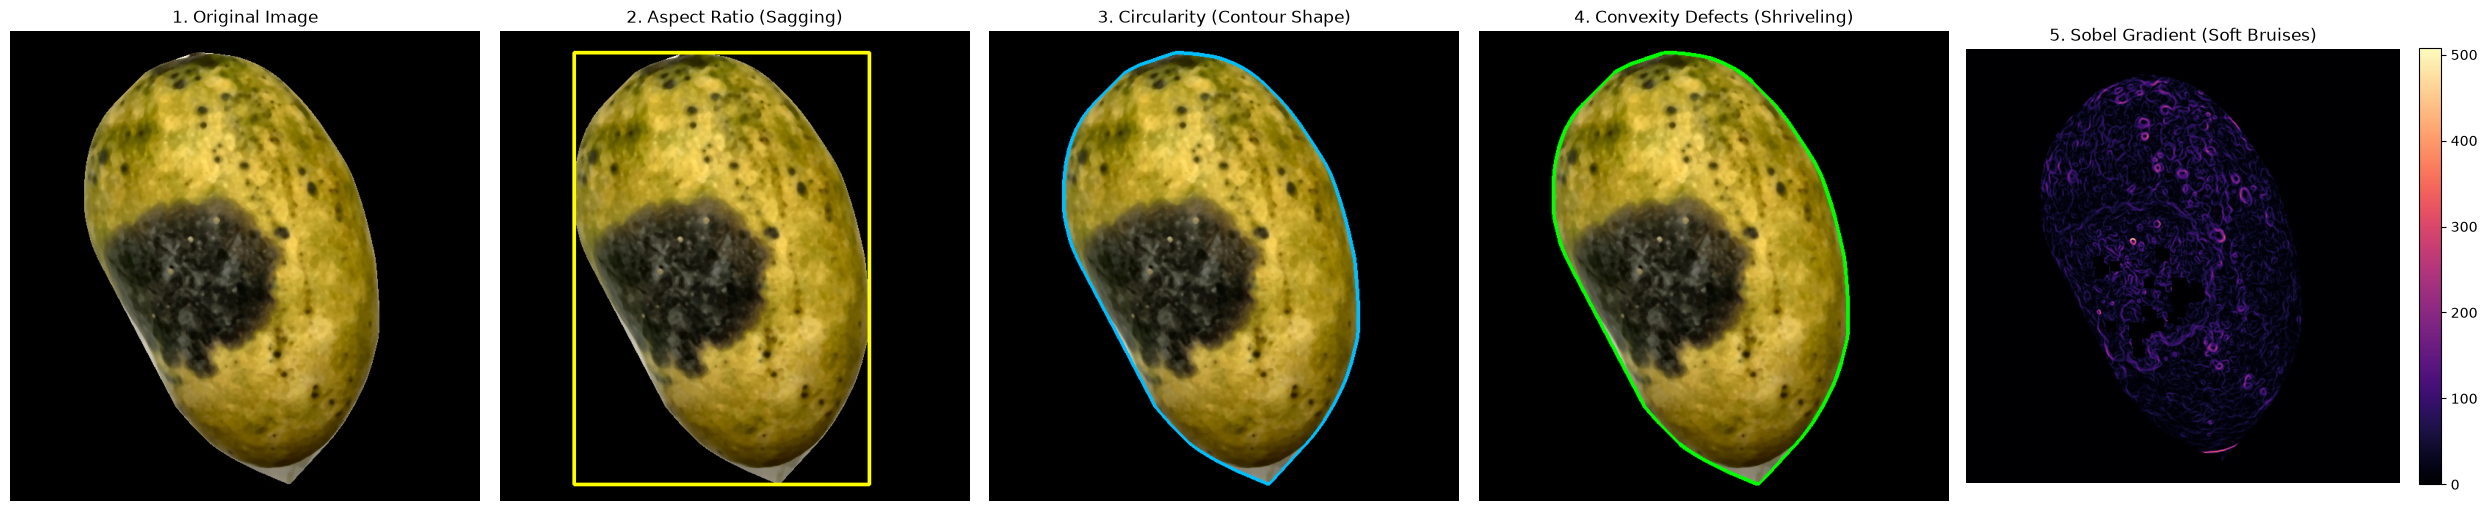

In [28]:
# Grab an overripe mango
sample_path = glob.glob(os.path.join(DATASET_ROOT, 'train', 'overripe', '*.*'))[0]
img_bgr = cv2.imread(sample_path)
gray, original_mask, interior_mask = get_preprocessing_masks(img_bgr)

# Get Contour
contours, _ = cv2.findContours(original_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
c = max(contours, key=cv2.contourArea)

# Setup canvases
img_aspect = cv2.cvtColor(img_bgr.copy(), cv2.COLOR_BGR2RGB)
img_circularity = cv2.cvtColor(img_bgr.copy(), cv2.COLOR_BGR2RGB)
img_defects = cv2.cvtColor(img_bgr.copy(), cv2.COLOR_BGR2RGB)

# 1. Aspect Ratio
x, y, w, h = cv2.boundingRect(c)
cv2.rectangle(img_aspect, (x, y), (x + w, y + h), (255, 255, 0), 4)

# 2. Circularity
cv2.drawContours(img_circularity, [c], -1, (0, 191, 255), 4)

# 3. Convexity Defects
hull = cv2.convexHull(c, returnPoints=False)
hull_points = cv2.convexHull(c, returnPoints=True)
cv2.drawContours(img_defects, [hull_points], -1, (0, 255, 0), 3)

defects = cv2.convexityDefects(c, hull)
if defects is not None:
    for i in range(defects.shape[0]):
        s, e, f, d = defects[i].flatten()
        farthest_point = tuple(c[f][0])
        depth = d / 256.0
        if depth > 3: 
            cv2.circle(img_defects, farthest_point, 20, (255, 0, 0), -1)

# 4. Sobel Gradient Heatmap
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag = np.sqrt(sobelx**2 + sobely**2)
sobel_mag_masked = cv2.bitwise_and(sobel_mag, sobel_mag, mask=interior_mask)

# --- PLOT EVERYTHING ---
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title("1. Original Image")
axes[0].axis('off')

axes[1].imshow(img_aspect)
axes[1].set_title("2. Aspect Ratio (Sagging)")
axes[1].axis('off')

axes[2].imshow(img_circularity)
axes[2].set_title("3. Circularity (Contour Shape)")
axes[2].axis('off')

axes[3].imshow(img_defects)
axes[3].set_title("4. Convexity Defects (Shriveling)")
axes[3].axis('off')

im = axes[4].imshow(sobel_mag_masked, cmap='magma')
axes[4].set_title("5. Sobel Gradient (Soft Bruises)")
axes[4].axis('off')
plt.colorbar(im, ax=axes[4], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


,Hybrid Algorithm,Accuracy (%),Macro F1
2,Scharr + Geometry,91.666667,0.916915
3,Canny + Geometry,89.583333,0.896596
1,Prewitt + Geometry,88.888889,0.890666
0,Sobel + Geometry,86.111111,0.863285


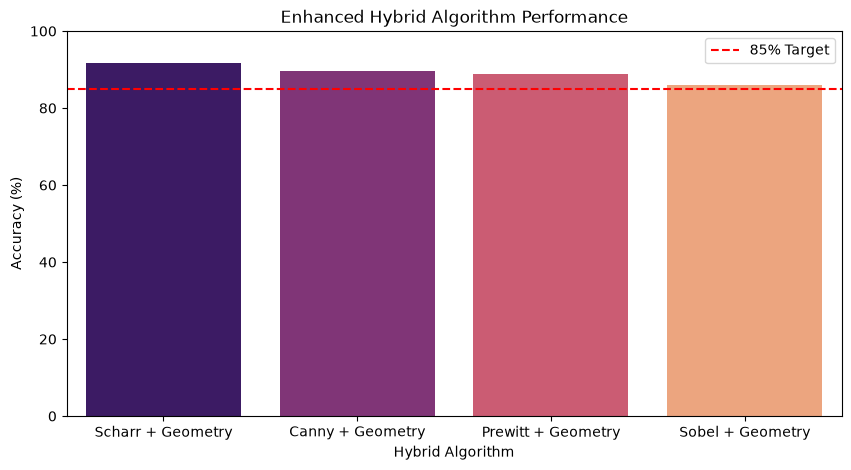


🏆 Absolute Best Model: Scharr + Geometry with 91.67% Accuracy

Classification Report for Best Model:
               precision    recall  f1-score   support

      unripe       0.87      0.96      0.91        48
  fully_ripe       0.91      0.88      0.89        48
    overripe       0.98      0.92      0.95        48

    accuracy                           0.92       144
   macro avg       0.92      0.92      0.92       144
weighted avg       0.92      0.92      0.92       144



In [29]:
# Benchmark the 4 Hybrid Models
geom_cols = ['circularity', 'aspect_ratio', 'convexity_defects', 'avg_sobel_gradient']
baseline_cols = ['sobel_density', 'prewitt_density', 'scharr_density', 'canny_density']

y_enh = df_enh['class'].map({'unripe': 0, 'fully_ripe': 1, 'overripe': 2})
is_train_enh = df_enh['split'] == 'train'

hybrid_results = []
models = {}

for edge_col in baseline_cols:
    feature_cols = [edge_col] + geom_cols
    
    X_train_enh = df_enh[is_train_enh][feature_cols]
    y_train_enh = y_enh[is_train_enh]
    X_test_enh = df_enh[~is_train_enh][feature_cols]
    y_test_enh = y_enh[~is_train_enh]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_enh)
    X_test_scaled = scaler.transform(X_test_enh)
    
    # Support Vector Machine (RBF) with Calibration to avoid FutureWarning
    base_svm = SVC(kernel='rbf', random_state=42)
    svm_model = CalibratedClassifierCV(base_svm, ensemble=False)
    svm_model.fit(X_train_scaled, y_train_enh)
    
    y_pred_enh = svm_model.predict(X_test_scaled)
    acc = accuracy_score(y_test_enh, y_pred_enh)
    f1 = f1_score(y_test_enh, y_pred_enh, average='macro')
    
    algo_name = edge_col.split('_')[0].capitalize() + " + Geometry"
    hybrid_results.append({
        'Hybrid Algorithm': algo_name,
        'Accuracy (%)': acc * 100,
        'Macro F1': f1,
        'edge_col': edge_col
    })
    
    models[algo_name] = {
        'model': svm_model,
        'scaler': scaler,
        'feature_cols': feature_cols,
        'y_pred': y_pred_enh,
        'acc': acc
    }

df_hybrid_bench = pd.DataFrame(hybrid_results).drop(columns=['edge_col']).sort_values(by='Accuracy (%)', ascending=False)
display(df_hybrid_bench)

plt.figure(figsize=(10, 5))
sns.barplot(x='Hybrid Algorithm', y='Accuracy (%)', hue='Hybrid Algorithm', data=df_hybrid_bench, palette='magma', legend=False)
plt.title('Enhanced Hybrid Algorithm Performance')
plt.ylim(0, 100)
plt.axhline(85, color='red', linestyle='--', label='85% Target')
plt.legend()
plt.show()

# Select the absolute best hybrid model
best_algo = df_hybrid_bench.iloc[0]['Hybrid Algorithm']
best_acc = models[best_algo]['acc']
best_model = models[best_algo]['model']
best_scaler = models[best_algo]['scaler']
best_features = models[best_algo]['feature_cols']
best_y_pred = models[best_algo]['y_pred']

print(f"\n🏆 Absolute Best Model: {best_algo} with {best_acc*100:.2f}% Accuracy")
print("\nClassification Report for Best Model:\n", classification_report(y_test_enh, best_y_pred, target_names=CLASSES))


### Visualization: Confusion Matrix (Best Hybrid Model)

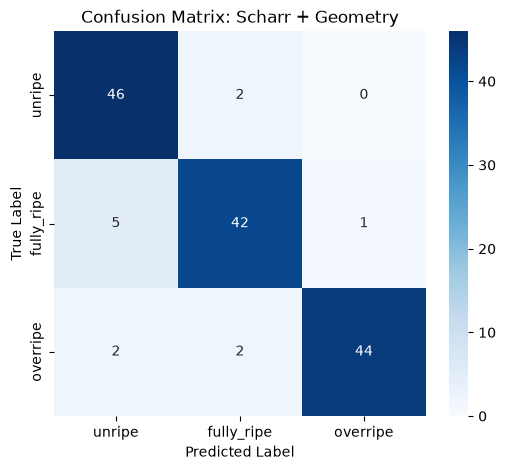

In [30]:
cm = confusion_matrix(y_test_enh, best_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title(f'Confusion Matrix: {best_algo}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


## 9. Verification: Alignment with Project SMART Objectives
1. **Accuracy Objective:** Must be $\ge 85\%$.
2. **Latency Objective:** Operational inference must be $< 200	ext{ ms}$ per image.


In [31]:
avg_latency = df_enh['latency_ms'].mean()

print(f"[Verification] Best Hybrid Model Accuracy: {best_acc*100:.2f}%")
if best_acc >= 0.85:
    print("✅ Objective 2 Fulfilled: Minimum classification accuracy rate of 85% achieved.")
else:
    print("❌ Objective 2 Failed.")

print(f"[Verification] Average Inference Latency: {avg_latency:.2f} ms")
if avg_latency < 200:
    print("✅ Objective 3 Fulfilled: Processing latency is well under 200 ms.")
else:
    print("❌ Objective 3 Failed.")


[Verification] Best Hybrid Model Accuracy: 91.67%
✅ Objective 2 Fulfilled: Minimum classification accuracy rate of 85% achieved.
[Verification] Average Inference Latency: 6.75 ms
✅ Objective 3 Fulfilled: Processing latency is well under 200 ms.


## 10. Model Export & Inference Serialization
Package the trained Scaler and best Hybrid SVM Model into a `.joblib` file for integration into the Streamlit prototype.

In [32]:
pipeline_package = {
    'scaler': best_scaler,
    'model': best_model,
    'features': best_features,
    'classes': {0: 'unripe', 1: 'fully_ripe', 2: 'overripe'}
}

export_path = os.path.join(OUTPUT_DIR, 'geometry_based_model.joblib')
joblib.dump(pipeline_package, export_path)
print(f"✅ Best Model pipeline successfully exported to {export_path}")


✅ Best Model pipeline successfully exported to ../output/geometry_based\geometry_based_model.joblib
